<a href="https://colab.research.google.com/github/williamvianaborges/utm_pricing_model/blob/main/BR_UTM_Pricing_Simulations_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BR-UTM Service-Provider Pricing Model

This Google Colab–compatible notebook reproduces the deterministic numerical experiments described in the paper **“Proposal of a Pricing Model for UTM Service Providers.”**

The notebook covers:

1. the provider-level tariff equation and hypothetical coefficients;
2. the worked tariff example;
3. synthetic operational and adverse-weather scenarios;
4. one-at-a-time sensitivity to operational variables;
5. standardized one-at-a-time sensitivity to tariff parameters;
6. the tornado chart based on ±25% parameter perturbations; and
7. sensitivity to the provider remuneration margin.

> **Important:** The numerical coefficients are hypothetical and are used only to illustrate the internal behavior of the pricing framework. They should not be interpreted as empirically calibrated BR-UTM tariffs.

The experiment is deterministic: no random sampling or statistical estimation is used.



## 1. Pricing model

The provider-side tariff is defined as

\[
P =
\alpha
+ \beta_1 T
+ \beta_2 A
+ \beta_3 H
+ \beta_4^1 V_1
+ \beta_4^2 V_2
+ \beta_4^3 V_3
+ \beta_4^4 V_4
+ \beta_4^5 V_5,
\]

where:

- \(T\): airspace reservation time;
- \(A\): reserved area;
- \(H\): peak-hour indicator (\(1\) for peak hour, \(0\) otherwise);
- \(V_0,\ldots,V_5\): procedural categories, with \(V_0\) as the base category.

The procedural categories used in the paper are:

- **V0:** Automatic in SARPAS;
- **V1:** Regional body analysis;
- **V2:** AIS;
- **V3:** NOTAM;
- **V4:** FPL validation;
- **V5:** Coordination agreement.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.float_format", lambda x: f"{x:.2f}")



## 2. Hypothetical parameters used in the simulation

The numerical specification used in the paper is

\[
P = 10 + 0.2T + 0.05A + 15H
+ 5V_1 + 10V_2 + 20V_3 + 25V_4 + 30V_5.
\]


In [3]:

PARAMS = {
    "alpha": 10.00,
    "beta_T": 0.20,
    "beta_A": 0.05,
    "beta_H": 15.00,
}

CATEGORY_SURCHARGE = {
    "V0": 0.00,
    "V1": 5.00,
    "V2": 10.00,
    "V3": 20.00,
    "V4": 25.00,
    "V5": 30.00,
}

CATEGORY_DESCRIPTION = {
    "V0": "Automatic in SARPAS",
    "V1": "Regional body analysis",
    "V2": "AIS",
    "V3": "NOTAM",
    "V4": "FPL validation",
    "V5": "Coordination agreement",
}

parameter_table = pd.DataFrame(
    [
        ["alpha", PARAMS["alpha"], "Base component of the tariff"],
        ["beta_1", PARAMS["beta_T"], "Increase per unit of reserved time"],
        ["beta_2", PARAMS["beta_A"], "Increase per unit of reserved area"],
        ["beta_3", PARAMS["beta_H"], "Peak-hour surcharge"],
        ["beta_4^1", CATEGORY_SURCHARGE["V1"], "Regional body analysis surcharge"],
        ["beta_4^2", CATEGORY_SURCHARGE["V2"], "AIS surcharge"],
        ["beta_4^3", CATEGORY_SURCHARGE["V3"], "NOTAM surcharge"],
        ["beta_4^4", CATEGORY_SURCHARGE["V4"], "FPL validation surcharge"],
        ["beta_4^5", CATEGORY_SURCHARGE["V5"], "Coordination agreement surcharge"],
    ],
    columns=["Parameter", "Value", "Interpretation"],
)

display(parameter_table)


,Parameter,Value,Interpretation
0,alpha,10.00,Base component of the tariff
1,beta_1,0.20,Increase per unit of reserved time
2,beta_2,0.05,Increase per unit of reserved area
3,beta_3,15.00,Peak-hour surcharge
4,beta_4^1,5.00,Regional body analysis surcharge
5,beta_4^2,10.00,AIS surcharge
6,beta_4^3,20.00,NOTAM surcharge
7,beta_4^4,25.00,FPL validation surcharge
8,beta_4^5,30.00,Coordination agreement surcharge



## 3. Tariff function

The function below implements the tariff equation directly. It also allows parameter values to be changed, which is useful for the sensitivity analysis.


In [4]:

def tariff(T, A, H, category, params=None, category_surcharge=None):
    """Compute the UTM service-provider tariff for one request."""
    if params is None:
        params = PARAMS
    if category_surcharge is None:
        category_surcharge = CATEGORY_SURCHARGE

    if category not in category_surcharge:
        raise ValueError(f"Unknown category: {category}")

    return (
        params["alpha"]
        + params["beta_T"] * T
        + params["beta_A"] * A
        + params["beta_H"] * H
        + category_surcharge[category]
    )



### Worked example from the paper

For \(T=30\), \(A=200\), \(H=1\), and category \(V_3\) (NOTAM):

\[
P = 10 + 0.2(30) + 0.05(200) + 15(1) + 20 = 61.
\]


In [5]:

example = {
    "T": 30,
    "A": 200,
    "H": 1,
    "category": "V3",
}

example_tariff = tariff(**example)

print(f"Estimated tariff = {example_tariff:.2f} monetary units")
assert np.isclose(example_tariff, 61.0)


Estimated tariff = 61.00 monetary units



## 4. Synthetic scenarios and adverse weather

Adverse weather is represented through its effect on effective reservation time rather than through a separate tariff surcharge:

\[
T_w = T(1+\delta_w),
\]

with:

- normal weather: \(\delta_w=0\);
- moderate adverse weather: \(\delta_w=0.25\);
- severe adverse weather: \(\delta_w=0.50\).

The scenarios below reproduce the operational profiles reported in the paper.


In [9]:

def weather_adjusted_time(T, delta_w):
    return T * (1 + delta_w)

scenario_specs = [
    ("Simple operation", "Normal", 0.00, 30, 100, 0, "V0", 21),
    ("Medium operation", "Normal", 0.00, 60, 300, 0, "V2", 47),
    ("Medium operation", "Moderate adverse", 0.25, 60, 300, 0, "V2", 50),
    ("Medium operation", "Severe adverse", 0.50, 60, 300, 0, "V2", 53),
    ("Peak-hour operation", "Normal", 0.00, 90, 300, 1, "V2", 68),
    ("Complex operation", "Normal", 0.00, 120, 500, 0, "V4", 84),
    ("Complex operation", "Moderate adverse", 0.25, 120, 500, 0, "V4", 90),
    ("Complex operation", "Severe adverse", 0.50, 120, 500, 0, "V4", 96),
    ("Complex peak-hour operation", "Normal", 0.00, 120, 500, 1, "V5", 104),
    ("Complex peak-hour operation", "Severe adverse", 0.50, 120, 500, 1, "V5", 116),
]

rows = []
for name, weather, delta_w, T_base, A, H, category, reported_tariff in scenario_specs:
    T_w = weather_adjusted_time(T_base, delta_w)
    computed_tariff = tariff(T=T_w, A=A, H=H, category=category)
    rows.append(
        {
            "Scenario": name,
            "Weather": weather,
            "delta_w": delta_w,
            "Baseline T": T_base,
            "T_w": T_w,
            "A": A,
            "H": H,
            "Category": category,
            "Computed tariff": computed_tariff,
        }
    )

scenario_df = pd.DataFrame(rows)
display(scenario_df)



,Scenario,Weather,delta_w,Baseline T,T_w,A,H,Category,Computed tariff
0,Simple operation,Normal,0.00,30,30.00,100,0,V0,21.00
1,Medium operation,Normal,0.00,60,60.00,300,0,V2,47.00
2,Medium operation,Moderate adverse,0.25,60,75.00,300,0,V2,50.00
3,Medium operation,Severe adverse,0.50,60,90.00,300,0,V2,53.00
4,Peak-hour operation,Normal,0.00,90,90.00,300,1,V2,68.00
5,Complex operation,Normal,0.00,120,120.00,500,0,V4,84.00
6,Complex operation,Moderate adverse,0.25,120,150.00,500,0,V4,90.00
7,Complex operation,Severe adverse,0.50,120,180.00,500,0,V4,96.00
8,Complex peak-hour operation,Normal,0.00,120,120.00,500,1,V5,104.00
9,Complex peak-hour operation,Severe adverse,0.50,120,180.00,500,1,V5,116.00



### Weather impact relative to the corresponding normal-weather profile

This cell quantifies the percentage increase generated by the weather-adjusted reservation time for the medium, complex, and complex peak-hour profiles.


In [10]:

weather_comparisons = []

comparison_groups = [
    ("Medium operation", "Normal"),
    ("Complex operation", "Normal"),
    ("Complex peak-hour operation", "Normal"),
]

for scenario_name, baseline_weather in comparison_groups:
    subset = scenario_df[scenario_df["Scenario"] == scenario_name].copy()
    baseline = subset.loc[subset["Weather"] == baseline_weather, "Computed tariff"].iloc[0]
    subset["Tariff change (%)"] = 100 * (subset["Computed tariff"] - baseline) / baseline
    weather_comparisons.append(subset[
        ["Scenario", "Weather", "T_w", "Computed tariff", "Tariff change (%)"]
    ])

weather_impact_df = pd.concat(weather_comparisons, ignore_index=True)
display(weather_impact_df)


,Scenario,Weather,T_w,Computed tariff,Tariff change (%)
0,Medium operation,Normal,60.00,47.00,0.00
1,Medium operation,Moderate adverse,75.00,50.00,6.38
2,Medium operation,Severe adverse,90.00,53.00,12.77
3,Complex operation,Normal,120.00,84.00,0.00
4,Complex operation,Moderate adverse,150.00,90.00,7.14
5,Complex operation,Severe adverse,180.00,96.00,14.29
6,Complex peak-hour operation,Normal,120.00,104.00,0.00
7,Complex peak-hour operation,Severe adverse,180.00,116.00,11.54



## 5. Sensitivity to operational variables

The paper evaluates one operational variable at a time while keeping the remaining components fixed.

The common baseline operation is reconstructed as:

\[
T=30,\quad A=200,\quad H=0,\quad V_0,
\]

which yields

\[
P_0 = 10 + 0.2(30) + 0.05(200)=26.
\]

The following cells vary:

- \(T\) from 30 to 120;
- \(A\) from 200 to 290;
- \(H\) from 0 to 1;
- procedural category from \(V_0\) to \(V_5\).


In [11]:

base_operation = {"T": 30, "A": 200, "H": 0, "category": "V0"}
base_tariff = tariff(**base_operation)

print(f"Baseline tariff = {base_tariff:.2f}")
assert np.isclose(base_tariff, 26.0)


Baseline tariff = 26.00


,T,Tariff
0,30,26.00
1,40,28.00
2,50,30.00
3,60,32.00
4,70,34.00
5,80,36.00
6,90,38.00
7,100,40.00
8,110,42.00
9,120,44.00


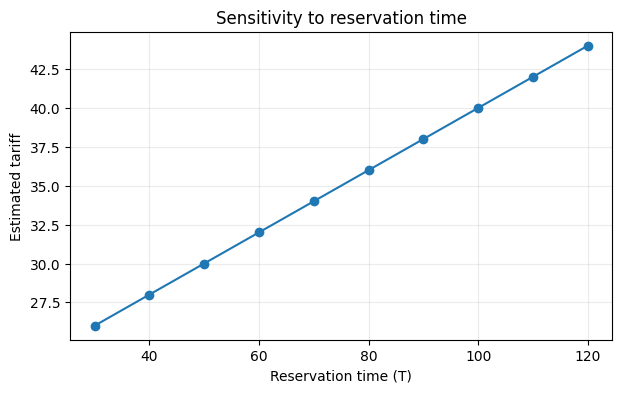

In [12]:

# Reservation-time sensitivity
T_values = np.arange(30, 121, 10)
T_sensitivity = pd.DataFrame({
    "T": T_values,
    "Tariff": [tariff(T=t, A=200, H=0, category="V0") for t in T_values]
})
display(T_sensitivity)

plt.figure(figsize=(7, 4))
plt.plot(T_sensitivity["T"], T_sensitivity["Tariff"], marker="o")
plt.xlabel("Reservation time (T)")
plt.ylabel("Estimated tariff")
plt.title("Sensitivity to reservation time")
plt.grid(alpha=0.25)
plt.show()


,A,Tariff
0,200,26.00
1,210,26.50
2,220,27.00
3,230,27.50
4,240,28.00
5,250,28.50
6,260,29.00
7,270,29.50
8,280,30.00
9,290,30.50


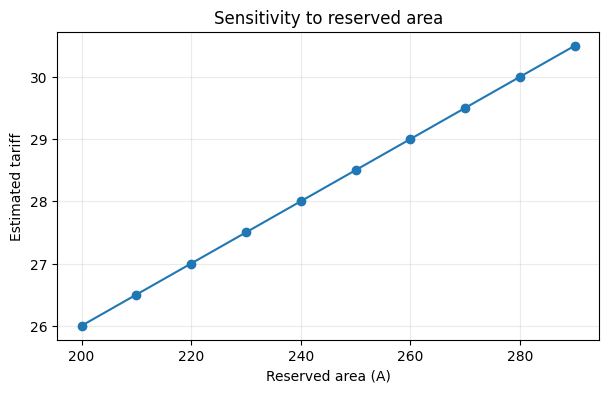

In [13]:

# Reserved-area sensitivity
A_values = np.arange(200, 291, 10)
A_sensitivity = pd.DataFrame({
    "A": A_values,
    "Tariff": [tariff(T=30, A=a, H=0, category="V0") for a in A_values]
})
display(A_sensitivity)

plt.figure(figsize=(7, 4))
plt.plot(A_sensitivity["A"], A_sensitivity["Tariff"], marker="o")
plt.xlabel("Reserved area (A)")
plt.ylabel("Estimated tariff")
plt.title("Sensitivity to reserved area")
plt.grid(alpha=0.25)
plt.show()


,H,Tariff
0,0,26.00
1,1,41.00


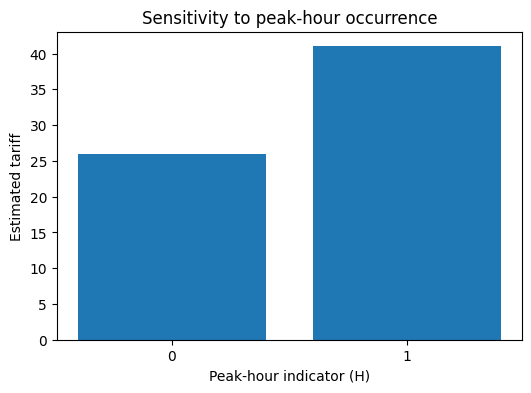

In [ ]:

# Peak-hour sensitivity
H_values = [0, 1]
H_sensitivity = pd.DataFrame({
    "H": H_values,
    "Tariff": [tariff(T=30, A=200, H=h, category="V0") for h in H_values]
})
display(H_sensitivity)

plt.figure(figsize=(6, 4))
plt.bar(H_sensitivity["H"].astype(str), H_sensitivity["Tariff"])
plt.xlabel("Peak-hour indicator (H)")
plt.ylabel("Estimated tariff")
plt.title("Sensitivity to peak-hour occurrence")
plt.show()


,Category,Description,Tariff
0,V0,Automatic in SARPAS,26.00
1,V1,Regional body analysis,31.00
2,V2,AIS,36.00
3,V3,NOTAM,46.00
4,V4,FPL validation,51.00
5,V5,Coordination agreement,56.00


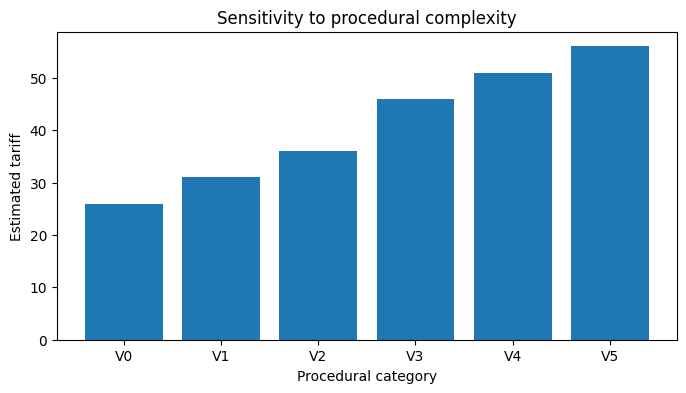

In [ ]:

# Procedural-category sensitivity
categories = list(CATEGORY_SURCHARGE.keys())
V_sensitivity = pd.DataFrame({
    "Category": categories,
    "Description": [CATEGORY_DESCRIPTION[c] for c in categories],
    "Tariff": [tariff(T=30, A=200, H=0, category=c) for c in categories],
})
display(V_sensitivity)

plt.figure(figsize=(8, 4))
plt.bar(V_sensitivity["Category"], V_sensitivity["Tariff"])
plt.xlabel("Procedural category")
plt.ylabel("Estimated tariff")
plt.title("Sensitivity to procedural complexity")
plt.show()



### Endpoint summary and reproducibility check

For \(T\), \(A\), and \(H\), the equation reproduces the endpoint values reported in the paper.

For the procedural-category comparison, however, the published sensitivity table reports a change from **26.0 to 66.0** when moving from \(V_0\) to \(V_5\). Using the paper's own coefficient for \(V_5\), \(\beta_4^5=30\), the equation gives **56.0**, not 66.0.

The notebook therefore preserves the published equation and coefficients and explicitly reports this difference instead of altering the model to force agreement with the table.


In [7]:

computed_operational_summary = pd.DataFrame([
    {
        "Variable": "T",
        "Initial value": 30,
        "Final value": 120,
        "Initial tariff": tariff(30, 200, 0, "V0"),
        "Final tariff": tariff(120, 200, 0, "V0"),
    },
    {
        "Variable": "A",
        "Initial value": 200,
        "Final value": 290,
        "Initial tariff": tariff(30, 200, 0, "V0"),
        "Final tariff": tariff(30, 290, 0, "V0"),
    },
    {
        "Variable": "H",
        "Initial value": 0,
        "Final value": 1,
        "Initial tariff": tariff(30, 200, 0, "V0"),
        "Final tariff": tariff(30, 200, 1, "V0"),
    },
    {
        "Variable": "V_j",
        "Initial value": "V0",
        "Final value": "V5",
        "Initial tariff": tariff(30, 200, 0, "V0"),
        "Final tariff": tariff(30, 200, 0, "V5"),
    },
])

computed_operational_summary["Delta P"] = (
    computed_operational_summary["Final tariff"]
    - computed_operational_summary["Initial tariff"]
)
computed_operational_summary["Delta P (%)"] = (
    100
    * computed_operational_summary["Delta P"]
    / computed_operational_summary["Initial tariff"]
)



display(computed_operational_summary)


,Variable,Initial value,Final value,Initial tariff,Final tariff,Delta P,Delta P (%)
0,T,30,120,26.00,44.00,18.00,69.23
1,A,200,290,26.00,30.50,4.50,17.31
2,H,0,1,26.00,41.00,15.00,57.69
3,V_j,V0,V5,26.00,56.00,30.00,115.38



## 6. Standardized sensitivity to tariff parameters

For direct comparison, each selected parameter is perturbed independently by

\[
\Delta \in \{-25\%,-10\%,0,+10\%,+25\%\},
\]

using

\[
\theta'=\theta(1+\Delta).
\]

The common reference request is:

\[
T=60,\quad A=300,\quad H=1,\quad V_2=1,
\]

for which the baseline tariff is

\[
P_0 = 10 + 0.2(60)+0.05(300)+15+10=62.
\]


In [16]:

reference_operation = {"T": 60, "A": 300, "H": 1, "category": "V2"}
P0 = tariff(**reference_operation)

print(f"Reference tariff P0 = {P0:.2f}")
assert np.isclose(P0, 62.0)


Reference tariff P0 = 62.00


In [17]:

perturbations = [-0.25, -0.10, 0.00, 0.10, 0.25]

parameter_baselines = {
    "alpha": PARAMS["alpha"],
    "beta_1": PARAMS["beta_T"],
    "beta_2": PARAMS["beta_A"],
    "beta_3": PARAMS["beta_H"],
    "beta_4^2": CATEGORY_SURCHARGE["V2"],
}

def tariff_with_one_parameter_changed(parameter_name, new_value):
    params = PARAMS.copy()
    surcharges = CATEGORY_SURCHARGE.copy()

    if parameter_name == "alpha":
        params["alpha"] = new_value
    elif parameter_name == "beta_1":
        params["beta_T"] = new_value
    elif parameter_name == "beta_2":
        params["beta_A"] = new_value
    elif parameter_name == "beta_3":
        params["beta_H"] = new_value
    elif parameter_name == "beta_4^2":
        surcharges["V2"] = new_value
    else:
        raise ValueError(parameter_name)

    return tariff(
        **reference_operation,
        params=params,
        category_surcharge=surcharges
    )

parameter_sensitivity_rows = []

for name, baseline_value in parameter_baselines.items():
    for delta in perturbations:
        new_value = baseline_value * (1 + delta)
        P_new = tariff_with_one_parameter_changed(name, new_value)
        parameter_sensitivity_rows.append({
            "Parameter": name,
            "Perturbation (%)": 100 * delta,
            "Parameter value": new_value,
            "Tariff": P_new,
            "Tariff deviation (%)": 100 * (P_new - P0) / P0,
        })

parameter_sensitivity_long = pd.DataFrame(parameter_sensitivity_rows)
display(parameter_sensitivity_long)


,Parameter,Perturbation (%),Parameter value,Tariff,Tariff deviation (%)
0,alpha,-25.00,7.50,59.50,-4.03
1,alpha,-10.00,9.00,61.00,-1.61
2,alpha,0.00,10.00,62.00,0.00
3,alpha,10.00,11.00,63.00,1.61
4,alpha,25.00,12.50,64.50,4.03
5,beta_1,-25.00,0.15,59.00,-4.84
6,beta_1,-10.00,0.18,60.80,-1.94
7,beta_1,0.00,0.20,62.00,0.00
8,beta_1,10.00,0.22,63.20,1.94
9,beta_1,25.00,0.25,65.00,4.84



### Reproduction of the ±25% parameter-sensitivity summary

The paper's table focuses on the endpoints of the standardized perturbation.


In [18]:

summary_rows = []

for name, baseline_value in parameter_baselines.items():
    low_value = baseline_value * 0.75
    high_value = baseline_value * 1.25
    low_tariff = tariff_with_one_parameter_changed(name, low_value)
    high_tariff = tariff_with_one_parameter_changed(name, high_value)
    max_dev = max(abs(low_tariff - P0), abs(high_tariff - P0)) / P0 * 100

    summary_rows.append({
        "Parameter": name,
        "Baseline value": baseline_value,
        "Value at -25%": low_value,
        "Tariff at -25%": low_tariff,
        "Value at +25%": high_value,
        "Tariff at +25%": high_tariff,
        "Maximum tariff deviation (%)": max_dev,
    })

parameter_sensitivity_summary = pd.DataFrame(summary_rows)
display(parameter_sensitivity_summary)


,Parameter,Baseline value,Value at -25%,Tariff at -25%,Value at +25%,Tariff at +25%,Maximum tariff deviation (%)
0,alpha,10.00,7.50,59.50,12.50,64.50,4.03
1,beta_1,0.20,0.15,59.00,0.25,65.00,4.84
2,beta_2,0.05,0.04,58.25,0.06,65.75,6.05
3,beta_3,15.00,11.25,58.25,18.75,65.75,6.05
4,beta_4^2,10.00,7.50,59.50,12.50,64.50,4.03



### Tornado chart

The chart shows the relative tariff deviation from \(P_0\) caused by a ±25% change in each selected parameter.


,Parameter,-25% deviation,+25% deviation,Max absolute deviation
0,alpha,-4.03,4.03,4.03
4,beta_4^2,-4.03,4.03,4.03
1,beta_1,-4.84,4.84,4.84
2,beta_2,-6.05,6.05,6.05
3,beta_3,-6.05,6.05,6.05


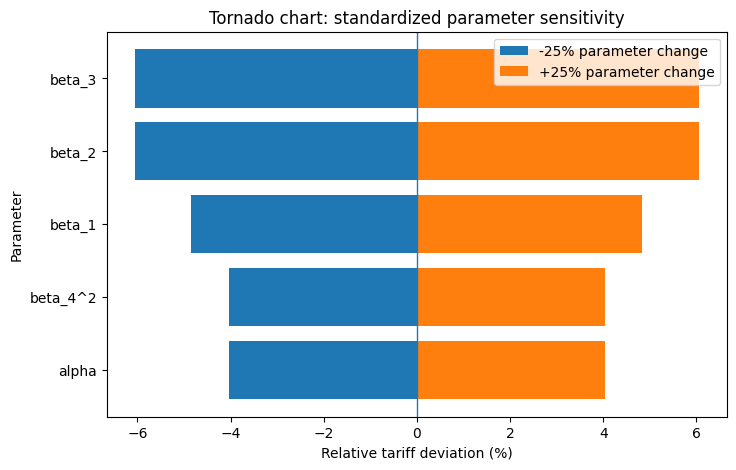

In [19]:

tornado_rows = []

for name, baseline_value in parameter_baselines.items():
    low_tariff = tariff_with_one_parameter_changed(name, baseline_value * 0.75)
    high_tariff = tariff_with_one_parameter_changed(name, baseline_value * 1.25)

    tornado_rows.append({
        "Parameter": name,
        "-25% deviation": 100 * (low_tariff - P0) / P0,
        "+25% deviation": 100 * (high_tariff - P0) / P0,
    })

tornado_df = pd.DataFrame(tornado_rows)
tornado_df["Max absolute deviation"] = tornado_df[
    ["-25% deviation", "+25% deviation"]
].abs().max(axis=1)
tornado_df = tornado_df.sort_values("Max absolute deviation")

display(tornado_df)

y = np.arange(len(tornado_df))

plt.figure(figsize=(8, 5))
plt.barh(y, tornado_df["-25% deviation"], label="-25% parameter change")
plt.barh(y, tornado_df["+25% deviation"], label="+25% parameter change")
plt.yticks(y, tornado_df["Parameter"])
plt.axvline(0, linewidth=1)
plt.xlabel("Relative tariff deviation (%)")
plt.ylabel("Parameter")
plt.title("Tornado chart: standardized parameter sensitivity")
plt.legend()
plt.show()



## 7. Sensitivity to the remuneration margin

The paper illustrates the remuneration margin \(m\) as a proportional adjustment to an underlying cost-based tariff:

\[
P(m)=(1+m)P_{\text{cost}},
\]

using \(P_{\text{cost}}=26\) monetary units and margins ranging from 0% to 50%.


,Margin m,Percentage,Tariff,Delta P (%)
0,0.00,0.00,26.00,0.00
1,0.10,10.00,28.60,10.00
2,0.20,20.00,31.20,20.00
3,0.30,30.00,33.80,30.00
4,0.40,40.00,36.40,40.00
5,0.50,50.00,39.00,50.00


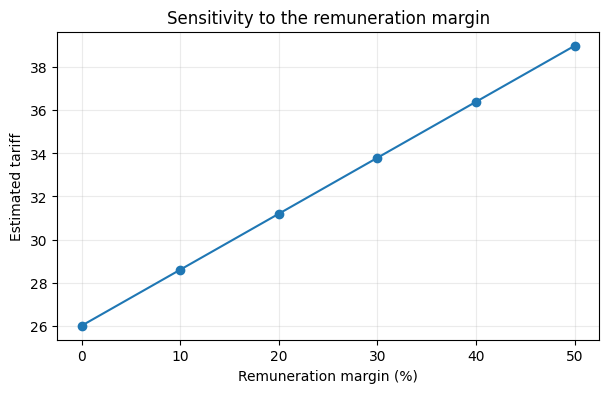

In [20]:

base_cost_tariff = 26.0
margins = np.arange(0.0, 0.51, 0.10)

margin_sensitivity = pd.DataFrame({
    "Margin m": margins,
    "Percentage": 100 * margins,
    "Tariff": base_cost_tariff * (1 + margins),
    "Delta P (%)": 100 * margins,
})

display(margin_sensitivity)

plt.figure(figsize=(7, 4))
plt.plot(
    margin_sensitivity["Percentage"],
    margin_sensitivity["Tariff"],
    marker="o"
)
plt.xlabel("Remuneration margin (%)")
plt.ylabel("Estimated tariff")
plt.title("Sensitivity to the remuneration margin")
plt.grid(alpha=0.25)
plt.show()



## 9. Export generated tables

Running the next cell writes the main simulation outputs to CSV files in the Colab working directory.


In [ ]:

scenario_df.to_csv("synthetic_scenarios.csv", index=False)
computed_operational_summary.to_csv("operational_sensitivity_summary.csv", index=False)
parameter_sensitivity_long.to_csv("parameter_sensitivity_all_perturbations.csv", index=False)
parameter_sensitivity_summary.to_csv("parameter_sensitivity_25pct.csv", index=False)
margin_sensitivity.to_csv("margin_sensitivity.csv", index=False)

print("CSV files created successfully.")


CSV files created successfully.
